<a href="https://colab.research.google.com/github/dipag6/Mycodes/blob/main/MR604_Rerun_18AUG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MR604 - clean re-run (18 August 2026)

Deepak Gajmer (MIT251589) - Melbourne Institute of Technology

Fresh 21-run grid on the corrected harness. Run every cell in order with Shift+Enter.

**First: Runtime -> Change runtime type -> GPU (A100).**

### Why this notebook replaces the old one

The 17 August run pointed `CODE` at a 29 July copy of `snnbench`. In that copy the spike-monitor hooks stayed attached while `measure_latency()` ran roughly 28,000 forward passes on `torch.rand()` noise. Those passes were added to the spike counters but never to the sample counter, so every spike rate, synaptic-operation count and energy figure came out 7-12x too high, the SNNs appeared more expensive than the ANN, and nothing warned. Section 2 below now refuses to continue unless the fix is present in the source it is about to run.

### Live sanity check

Mean spike rate should sit between **0.08 and 0.12** and rise slowly with T. ANN rows print `s_bar None`, which is normal. If you see a mean near 0.5, a mean that *falls* as T rises, or a negative `pct_saving_si`, the monitor is miscounting again - stop the run.

### Expected pacing (measured on A100-SXM4-40GB)

| stage | per seed | x3 seeds |
|---|---|---|
| ANN baseline | ~4.6 min | ~14 min |
| STBP T=4 | ~6.7 min | ~20 min |
| STBP T=8 | ~11.5 min | ~35 min |
| STBP T=16 | ~22.6 min | ~68 min |
| QCFS T=2,4,8 | ~5.1 min each | ~46 min |

Total about 3 hours, roughly 17 compute units. Colab's idle timeout watches *browser activity*, not your job - keep this tab open and stop the machine sleeping.

## 1 - GPU check

In [1]:
import torch
assert torch.cuda.is_available(), 'No GPU. Runtime -> Change runtime type -> GPU, then rerun.'
print('GPU  :', torch.cuda.get_device_name(0))
print('VRAM :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
print('torch:', torch.__version__)

GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB
torch: 2.11.0+cu128


## 2 - Mount Drive, set paths, verify the harness

**Re-run this cell after any runtime restart.** Every `!` command below interpolates the Python variables defined here; if they are undefined, IPython leaves the braces literal and the shell command silently does nothing. That is exactly how the gates step was lost on 17 August.

This cell must end with `instrumentation check: PASS`.

In [2]:
from google.colab import drive; drive.mount('/content/drive')
import os, sys, subprocess

BASE    = '/content/drive/MyDrive/SNN-ImageRecognition-Experiment'
CODE    = BASE + '/code'
RESULTS = BASE + '/results'
CKPTS   = BASE + '/checkpoints'
TABLES  = BASE + '/tables'
FIGURES = BASE + '/figures'
DATA    = '/content/data'      # 11 MB dataset, keep it on local disk, it is faster

for d in (RESULTS, CKPTS, TABLES, FIGURES, DATA):
    os.makedirs(d, exist_ok=True)

assert os.path.exists(CODE + '/run.py'), 'run.py not found at ' + CODE
os.chdir(CODE); sys.path.insert(0, CODE)
print('cwd:', os.getcwd())

# --- instrumentation guard --------------------------------------------------
# Reads snnbench/engine.py and refuses if the Section 4.4.1 fix is missing.
_chk = subprocess.run([sys.executable, 'tools/verify_instrumentation.py'],
                      capture_output=True, text=True)
print(_chk.stdout or _chk.stderr)
assert _chk.returncode == 0, 'STALE HARNESS at ' + CODE + ' -- do not train.'

Mounted at /content/drive
cwd: /content/drive/MyDrive/SNN-ImageRecognition-Experiment/code
Instrumentation check on /content/drive/MyDrive/SNN-ImageRecognition-Experiment/code/snnbench/engine.py
  [OK ] spike hooks detached before latency measurement
  [OK ] per-layer rate above 1.0 raises rather than warns
  [OK ] sample counter incremented inside the accuracy loop

instrumentation check: PASS -- safe to train



## 3 - Install

In [3]:
!pip install -q spikingjelly==0.0.0.0.14 fvcore tqdm tabulate

# spikingjelly.__version__ does not exist - the top-level package is empty.
# importlib.metadata reads the installed distribution metadata instead.
import importlib.metadata as md
for pkg in ('torch', 'torchvision', 'spikingjelly', 'fvcore'):
    try:
        print(f'{pkg:<14}', md.version(pkg))
    except md.PackageNotFoundError:
        print(f'{pkg:<14} NOT INSTALLED')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 8.4 MB/s eta 0:00:00
torch          2.11.0+cu128
torchvision    0.26.0+cu128
spikingjelly   0.0.0.0.14
fvcore         0.1.5.post20221221


In [4]:
# Confirms the SpikingJelly symbols this code calls actually exist, and that
# ParametricLIFNode accepts v_reset (needed for soft reset).
!python tools/check_install.py

ENVIRONMENT CHECK
  torch          2.11.0+cu128
  torchvision    0.26.0+cu128
  spikingjelly   0.0.0.0.14
  fvcore         0.1.5.post20221221
  numpy          2.0.2
  pandas         2.2.2

  CUDA available: True
  GPU           : NVIDIA A100-SXM4-40GB
  VRAM          : 42.4 GB

  SpikingJelly API:
    OK    neuron.ParametricLIFNode
    OK    neuron.IFNode
    OK    surrogate.ATan
    OK    functional.reset_net
    OK    ParametricLIFNode accepts v_reset
    OK    ParametricLIFNode accepts init_tau
    OK    ParametricLIFNode accepts step_mode
    OK    forward pass runs, emitted 26 spikes
RESULT: PASS


## 4 - Get the dataset

Must print `dataset check: PASS`. Doing it explicitly means a download problem shows up in 10 seconds rather than 20 minutes into training.

In [5]:
assert 'DATA' in globals(), 'Run the section 2 setup cell first.'
!python run.py data --data-root {DATA}

mirrors tried, in order:
   https://ossci-datasets.s3.amazonaws.com/mnist/
   http://yann.lecun.com/exdb/mnist/
100% 9.91M/9.91M [00:00<00:00, 14.4MB/s]
100% 28.9k/28.9k [00:00<00:00, 352kB/s]
100% 1.65M/1.65M [00:00<00:00, 3.33MB/s]
100% 4.54k/4.54k [00:00<00:00, 16.9MB/s]

train images : 60,000   (expected 60,000)
test images  : 10,000   (expected 10,000)
image shape  : (1, 28, 28)   (expected (1, 28, 28))
pixel range  : [0.000, 1.000]   (expected [0.000, 1.000])
classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
test class counts: [980, 1135, 1032, 1010, 982, 892, 958, 1028, 974, 1009]

dataset check: PASS
stored at: /content/data/MNIST/raw


## 5 - Verify the operation counts

Trains nothing, takes seconds. Must print `verification: PASS`.

fvcore reports 4,316,672 against the analytical 4,241,152. The 75,520 gap is BatchNorm affine ops, which the SNN convention folds into the preceding convolution; the script predicts that number exactly rather than allowing a tolerance.

In [6]:
!python run.py verify

--- operation count verification ---
  conv1    MAC=   225,792  params=      320  sites=  25,088
  conv2    MAC= 3,612,672  params=   18,496  sites=  12,544
  fc1      MAC=   401,408  params=  401,536  sites=     128
  fc2      MAC=     1,280  params=    1,290  sites=      10
  TOTAL    MAC= 4,241,152  params=  422,090  sites=  37,770
  fvcore total: 4,316,672   analytical (conv+fc only): 4,241,152   delta +75,520
    delta explained exactly: BatchNorm affine ops = 2 x 37,760 = 75,520. fvcore counts BN; the SNN accounting convention folds BN into the preceding conv at inference and excludes it.
    -> counts AGREE under the stated convention.
  verification: PASS

--- break-even thresholds (gate G1) ---
   T   s* @0.9pJ   s* @1.89pJ                    binding?
   2      2.5556       1.2169             neither binding
   4      1.2778       0.6085             calibrated only
   8      0.6389       0.3042                both binding
  16      0.3194       0.1521                both bindi

## 6 - Optional smoke test (~20 min)

Every configuration at 2 epochs, one seed. Proves the pipeline before you commit 3 hours. Accuracy will be below the final figures; what matters is that spike rates look sane and no warning fires.

Skip it if you want - section 5 already validated the counts and section 2 validated the instrumentation.

In [7]:
assert 'RESULTS' in globals(), 'Run the section 2 setup cell first.'
# Writes to a throwaway directory so it cannot contaminate the real grid.
!python run.py smoke --out-dir /content/smoke_results --ckpt-dir /content/smoke_ckpts --data-root {DATA}


7 configurations queued

--- operation count verification ---
  conv1    MAC=   225,792  params=      320  sites=  25,088
  conv2    MAC= 3,612,672  params=   18,496  sites=  12,544
  fc1      MAC=   401,408  params=  401,536  sites=     128
  fc2      MAC=     1,280  params=    1,290  sites=      10
  TOTAL    MAC= 4,241,152  params=  422,090  sites=  37,770
  fvcore total: 4,316,672   analytical (conv+fc only): 4,241,152   delta +75,520
    delta explained exactly: BatchNorm affine ops = 2 x 37,760 = 75,520. fvcore counts BN; the SNN accounting convention folds BN into the preceding conv at inference and excludes it.
    -> counts AGREE under the stated convention.
  verification: PASS

### [1/7]
RUN ann_s42   pathway=ann T=0 seed=42 epochs=2 encoding=rate backend=spikingjelly
/content/drive/MyDrive/SNN-ImageRecognition-Experiment/code/snnbench/engine.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

## 7 - The full grid (~3 h)

21 runs: 3 ANN + 9 Path A + 9 Path B. Path B is additionally evaluated under both input encodings at no training cost, giving 30 result rows.

**Re-run this same cell after any disconnect.** Finished runs are skipped, partial runs resume from the last epoch checkpoint, and checkpoints are written to Drive every epoch.

In [8]:
assert 'RESULTS' in globals(), 'Run the section 2 setup cell first - the paths are undefined and this cell would do nothing.'
!python run.py grid --epochs 64 --out-dir {RESULTS} --ckpt-dir {CKPTS} --data-root {DATA}


21 configurations queued

--- operation count verification ---
  conv1    MAC=   225,792  params=      320  sites=  25,088
  conv2    MAC= 3,612,672  params=   18,496  sites=  12,544
  fc1      MAC=   401,408  params=  401,536  sites=     128
  fc2      MAC=     1,280  params=    1,290  sites=      10
  TOTAL    MAC= 4,241,152  params=  422,090  sites=  37,770
  fvcore total: 4,316,672   analytical (conv+fc only): 4,241,152   delta +75,520
    delta explained exactly: BatchNorm affine ops = 2 x 37,760 = 75,520. fvcore counts BN; the SNN accounting convention folds BN into the preceding conv at inference and excludes it.
    -> counts AGREE under the stated convention.
  verification: PASS

### [1/21]
RUN ann_s42   pathway=ann T=0 seed=42 epochs=64 encoding=rate backend=spikingjelly
/content/drive/MyDrive/SNN-ImageRecognition-Experiment/code/snnbench/engine.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` inste

## 8 - Gates, tables, figures

`run.py grid` already writes `_gates.json` at the end, so the first cell here is a re-application rather than the only chance to get it.

In [9]:
assert 'RESULTS' in globals(), 'Run the section 2 setup cell first.'
!python run.py gates --out-dir {RESULTS}

VALIDITY GATE REPORT (Thesis Section 3.7 / Table 5.10)
config          acc mean     sd    s_bar   G1 th   G1 si    G2             admit
------------------------------------------------------------------------------------------------
ann_T0             99.27   0.04      n/a     n/a     n/a  PASS          baseline
qcfs_T2            89.76   2.09   0.0827    PASS    PASS  FAIL      BLOCKED (G2)
qcfs_T4            92.04   1.93   0.1045    PASS    PASS  FAIL      BLOCKED (G2)
qcfs_T8            93.05   0.87   0.1147    PASS    PASS  PASS             th+si
qcfs_direct_T2     98.55   0.11   0.0855    PASS    PASS  PASS             th+si
qcfs_direct_T4     97.98   0.47   0.1000    PASS    PASS  PASS             th+si
qcfs_direct_T8     96.64   0.78   0.1120    PASS    PASS  PASS             th+si
stbp_T16           99.36   0.05   0.0848    PASS    FAIL  PASS  theoretical only
stbp_T4            99.30   0.06   0.0782    PASS    PASS  PASS             th+si
stbp_T8            99.35   0.02   0.08

In [10]:
assert 'RESULTS' in globals(), 'Run the section 2 setup cell first.'
!python analyse.py --out-dir {RESULTS} --tables-dir {TABLES} --figures-dir {FIGURES}

  figures -> /content/drive/MyDrive/SNN-ImageRecognition-Experiment/figures

         config  accuracy_mean  accuracy_sd  spike_rate_mean  latency_gpu_ms  latency_cpu_ms   e_th_uj   e_si_uj G1_th G1_si
       ANN fp32      99.270000     0.036056              NaN        0.003237        0.449911 19.509299 19.509299   n/a   n/a
       QCFS T=2      89.756667     2.094692         0.082663        0.010629        2.301766  0.822705  1.727680  PASS  PASS
       QCFS T=4      92.043333     1.932494         0.104503        0.020045        4.189543  1.435037  3.013577  PASS  PASS
       QCFS T=8      93.050000     0.871952         0.114720        0.039180        7.928388  3.520032  7.392068  PASS  PASS
QCFS_DIRECT T=2      98.553333     0.105040         0.085547        0.010685        2.258267  2.672115  3.326427  PASS  PASS
QCFS_DIRECT T=4      97.983333     0.465439         0.099987        0.019969        4.105644  5.284569  6.527564  PASS  PASS
QCFS_DIRECT T=8      96.643333     0.784496     



## Table 5.4 Baselines

| config   |   accuracy_mean |   accuracy_sd |   latency_gpu_ms |   latency_cpu_ms |   e_th_uj |
|:---------|----------------:|--------------:|-----------------:|-----------------:|----------:|
| ANN fp32 |         99.2700 |        0.0361 |           0.0032 |           0.4499 |   19.5093 |

## Table 5.5 Path A

| pathway   |   T |   n_seeds |   accuracy_mean |   accuracy_sd |   spike_rate_mean |        n_sop |   e_th_uj |   e_si_uj |   latency_gpu_ms |   latency_cpu_ms |   edp_th |   edp_si |   aep_th |   aep_si | config    |
|:----------|----:|----------:|----------------:|--------------:|------------------:|-------------:|----------:|----------:|-----------------:|-----------------:|---------:|---------:|---------:|---------:|:----------|
| stbp      |   4 |         3 |         99.2967 |        0.0643 |            0.0782 | 1081651.4743 |    0.9735 |    2.0443 |           0.0271 |           5.7584 |   5.6103 |  11.7815 |   0.0068 |   0.0144 | STBP T=4  |
| stbp      |   8 |         3 |         99.3500 |        0.0200 |            0.0824 | 2399887.1533 |    2.1599 |    4.5358 |           0.0533 |          11.8102 |  25.5291 |  53.6110 |   0.0140 |   0.0295 | STBP T=8  |
| stbp      |  16 |         3 |         99.3633 |        0.0503 |            0.0848 | 5215528.2247 |    4.6940 |    9.8573 |           0.1055 |          22.6300 | 106.1916 | 223.0023 |   0.0299 |   0.0627 | STBP T=16 |

## Table 5.6 Path A per-layer

| config    | layer   |   spike_rate |   s_star_th |   s_star_si | G1_th   | G1_si   |
|:----------|:--------|-------------:|------------:|------------:|:--------|:--------|
| STBP T=16 | sn1     |       0.0265 |      0.3194 |      0.1521 | PASS    | PASS    |
| STBP T=16 | sn2     |       0.0340 |      0.3194 |      0.1521 | PASS    | PASS    |
| STBP T=16 | sn3     |       0.1939 |      0.3194 |      0.1521 | PASS    | FAIL    |
| STBP T=4  | sn1     |       0.0218 |      1.2778 |      0.6085 | PASS    | PASS    |
| STBP T=4  | sn2     |       0.0227 |      1.2778 |      0.6085 | PASS    | PASS    |
| STBP T=4  | sn3     |       0.1902 |      1.2778 |      0.6085 | PASS    | PASS    |
| STBP T=8  | sn1     |       0.0242 |      0.6389 |      0.3042 | PASS    | PASS    |
| STBP T=8  | sn2     |       0.0290 |      0.6389 |      0.3042 | PASS    | PASS    |
| STBP T=8  | sn3     |       0.1939 |      0.6389 |      0.3042 | PASS    | PASS    |

## Table 5.7 Path B

| pathway   |   T |   n_seeds |   accuracy_mean |   accuracy_sd |   spike_rate_mean |        n_sop |   e_th_uj |   e_si_uj |   latency_gpu_ms |   latency_cpu_ms |   edp_th |   edp_si |   aep_th |   aep_si | config   |
|:----------|----:|----------:|----------------:|--------------:|------------------:|-------------:|----------:|----------:|-----------------:|-----------------:|---------:|---------:|---------:|---------:|:---------|
| qcfs      |   2 |         3 |         89.7567 |        2.0947 |            0.0827 |  914116.2709 |    0.8227 |    1.7277 |           0.0106 |           2.3018 |   1.8949 |   3.9792 |   0.0850 |   0.1784 | QCFS T=2 |
| qcfs      |   4 |         3 |         92.0433 |        1.9325 |            0.1045 | 1594485.2051 |    1.4350 |    3.0136 |           0.0200 |           4.1895 |   6.0139 |  12.6293 |   0.1135 |   0.2384 | QCFS T=4 |
| qcfs      |   8 |         3 |         93.0500 |        0.8720 |            0.1147 | 3911146.9475 |    3.5200 |    7.3921 |           0.0392 |           7.9284 |  27.9005 |  58.5910 |   0.2460 |   0.5165 | QCFS T=8 |

## Table 5.8 Path B per-layer

| config   | layer   |   spike_rate |   s_star_th |   s_star_si | G1_th   | G1_si   |
|:---------|:--------|-------------:|------------:|------------:|:--------|:--------|
| QCFS T=2 | sn1     |       0.0359 |      2.5556 |      1.2169 | PASS    | PASS    |
| QCFS T=2 | sn2     |       0.0682 |      2.5556 |      1.2169 | PASS    | PASS    |
| QCFS T=2 | sn3     |       0.1438 |      2.5556 |      1.2169 | PASS    | PASS    |
| QCFS T=4 | sn1     |       0.0271 |      1.2778 |      0.6085 | PASS    | PASS    |
| QCFS T=4 | sn2     |       0.0755 |      1.2778 |      0.6085 | PASS    | PASS    |
| QCFS T=4 | sn3     |       0.2110 |      1.2778 |      0.6085 | PASS    | PASS    |
| QCFS T=8 | sn1     |       0.0465 |      0.6389 |      0.3042 | PASS    | PASS    |
| QCFS T=8 | sn2     |       0.0919 |      0.6389 |      0.3042 | PASS    | PASS    |
| QCFS T=8 | sn3     |       0.2057 |      0.6389 |      0.3042 | PASS    | PASS    |

## Table 5.9 Unified four-metric

| config          |   accuracy_mean |   accuracy_sd |   spike_rate_mean |   latency_gpu_ms |   latency_cpu_ms |   e_th_uj |   e_si_uj | G1_th   | G1_si   |
|:----------------|----------------:|--------------:|------------------:|-----------------:|-----------------:|----------:|----------:|:--------|:--------|
| ANN fp32        |         99.2700 |        0.0361 |          nan      |           0.0032 |           0.4499 |   19.5093 |   19.5093 | n/a     | n/a     |
| QCFS T=2        |         89.7567 |        2.0947 |            0.0827 |           0.0106 |           2.3018 |    0.8227 |    1.7277 | PASS    | PASS    |
| QCFS T=4        |         92.0433 |        1.9325 |            0.1045 |           0.0200 |           4.1895 |    1.4350 |    3.0136 | PASS    | PASS    |
| QCFS T=8        |         93.0500 |        0.8720 |            0.1147 |           0.0392 |           7.9284 |    3.5200 |    7.3921 | PASS    | PASS    |
| QCFS_DIRECT T=2 |         98.5533 |        0.1050 |            0.0855 |           0.0107 |           2.2583 |    2.6721 |    3.3264 | PASS    | PASS    |
| QCFS_DIRECT T=4 |         97.9833 |        0.4654 |            0.1000 |           0.0200 |           4.1056 |    5.2846 |    6.5276 | PASS    | PASS    |
| QCFS_DIRECT T=8 |         96.6433 |        0.7845 |            0.1120 |           0.0388 |           8.1452 |   11.3642 |   14.7247 | PASS    | PASS    |
| STBP T=4        |         99.2967 |        0.0643 |            0.0782 |           0.0271 |           5.7584 |    0.9735 |    2.0443 | PASS    | PASS    |
| STBP T=8        |         99.3500 |        0.0200 |            0.0824 |           0.0533 |          11.8102 |    2.1599 |    4.5358 | PASS    | PASS    |
| STBP T=16       |         99.3633 |        0.0503 |            0.0848 |           0.1055 |          22.6300 |    4.6940 |    9.8573 | PASS    | FAIL    |

## Table 5.11 Composite rankings

| config          |   edp_th |   edp_si |   aep_th |   aep_si |   rank_edp_th |   rank_edp_si |   rank_aep_th |   rank_aep_si |
|:----------------|---------:|---------:|---------:|---------:|--------------:|--------------:|--------------:|--------------:|
| QCFS T=2        |   1.8949 |   3.9792 |   0.0850 |   0.1784 |             1 |             1 |             5 |             7 |
| STBP T=4        |   5.6103 |  11.7815 |   0.0068 |   0.0144 |             2 |             4 |             1 |             1 |
| QCFS T=4        |   6.0139 |  12.6293 |   0.1135 |   0.2384 |             3 |             5 |             7 |             8 |
| QCFS_DIRECT T=2 |   6.0332 |   7.5096 |   0.0386 |   0.0481 |             4 |             2 |             4 |             3 |
| ANN fp32        |   8.7775 |   8.7775 |   0.1424 |   0.1424 |             5 |             3 |             8 |             6 |
| QCFS_DIRECT T=4 |  21.7004 |  26.8079 |   0.1065 |   0.1315 |             6 |             6 |             6 |             5 |
| STBP T=8        |  25.5291 |  53.6110 |   0.0140 |   0.0295 |             7 |             7 |             2 |             2 |
| QCFS T=8        |  27.9005 |  58.5910 |   0.2460 |   0.5165 |             8 |             8 |             9 |            10 |
| QCFS_DIRECT T=8 |  92.5785 | 119.9671 |   0.3828 |   0.4971 |             9 |             9 |            10 |             9 |
| STBP T=16       | 106.1916 | 223.0023 |   0.0299 |   0.0627 |            10 |            10 |             3 |             4 |

## Table 6.1 Deployment

| profile         |   power_budget_mW |   accuracy_floor | recommend_theoretical   |   edp_theoretical |   arithmetic_power_uW_theoretical | recommend_calibrated   |   edp_calibrated |   arithmetic_power_uW_calibrated | selection_stable   |
|:----------------|------------------:|-----------------:|:------------------------|------------------:|----------------------------------:|:-----------------------|-----------------:|---------------------------------:|:-------------------|
| ultra_low_power |                10 |          95.0000 | STBP T=4                |            5.6103 |                            9.7349 | QCFS_DIRECT T=2        |           7.5096 |                          33.2643 | False              |
| balanced        |                50 |          98.0000 | STBP T=4                |            5.6103 |                            9.7349 | QCFS_DIRECT T=2        |           7.5096 |                          33.2643 | False              |
| high_accuracy   |               100 |          99.0000 | STBP T=4                |            5.6103 |                            9.7349 | ANN fp32               |           8.7775 |                         195.0930 | False              |

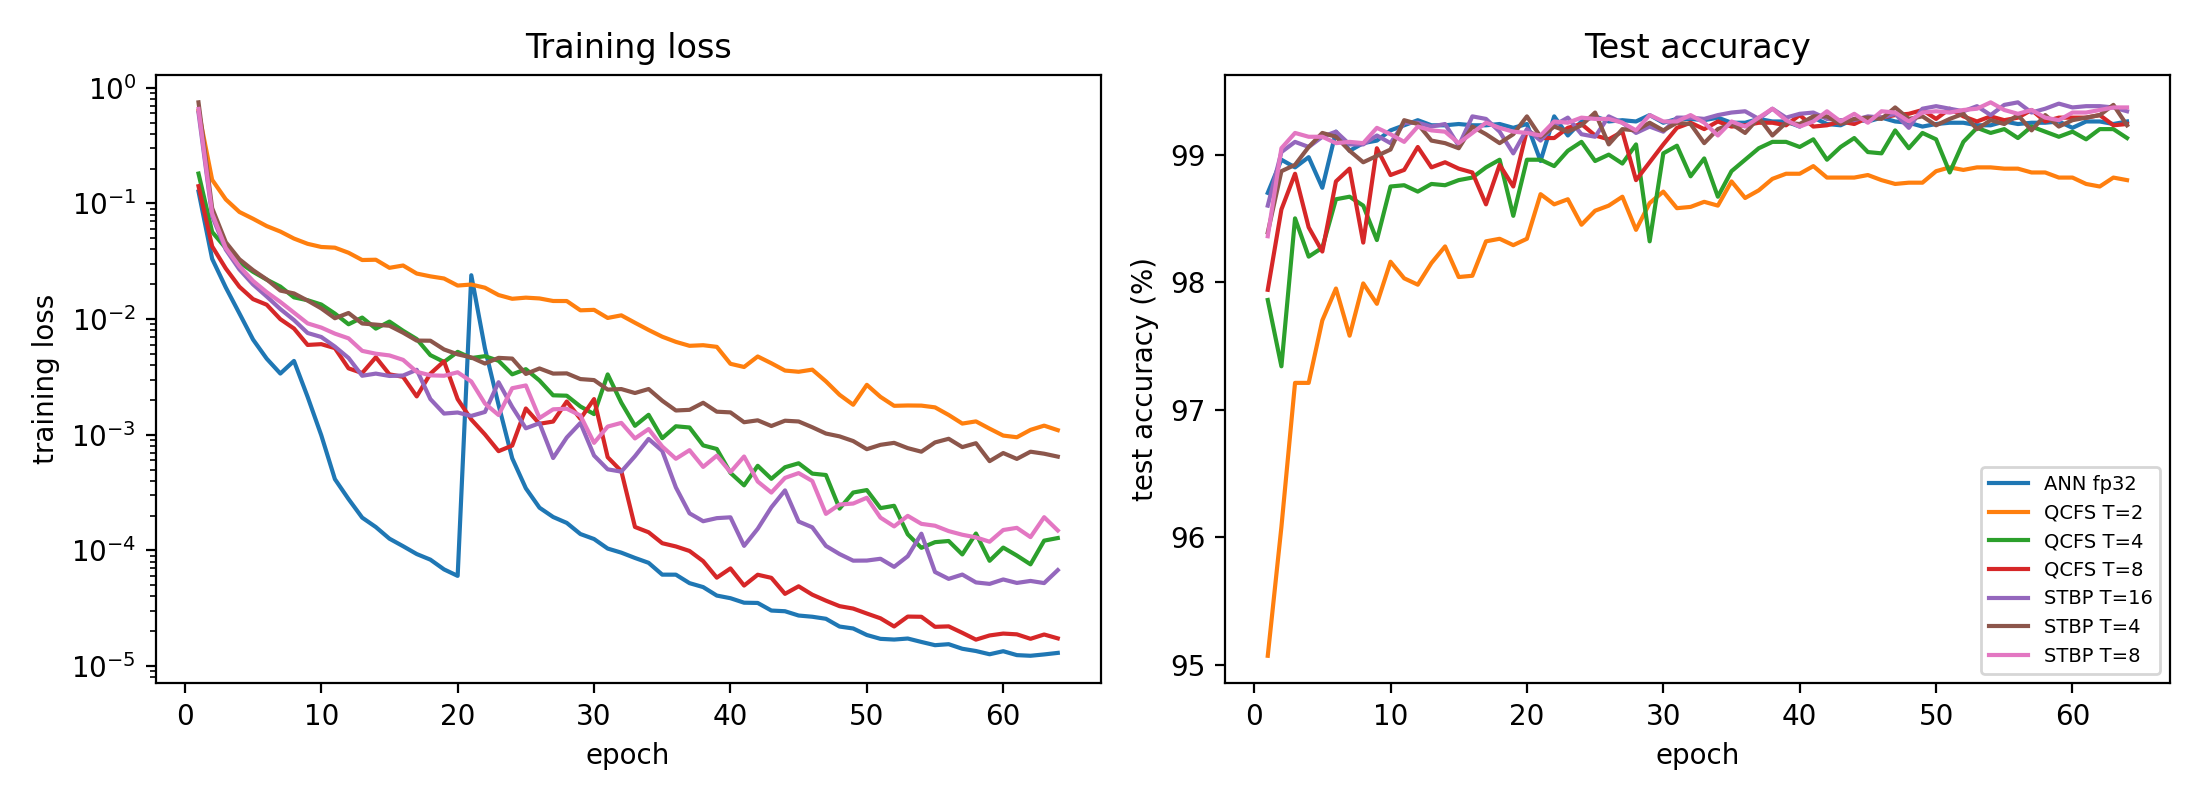

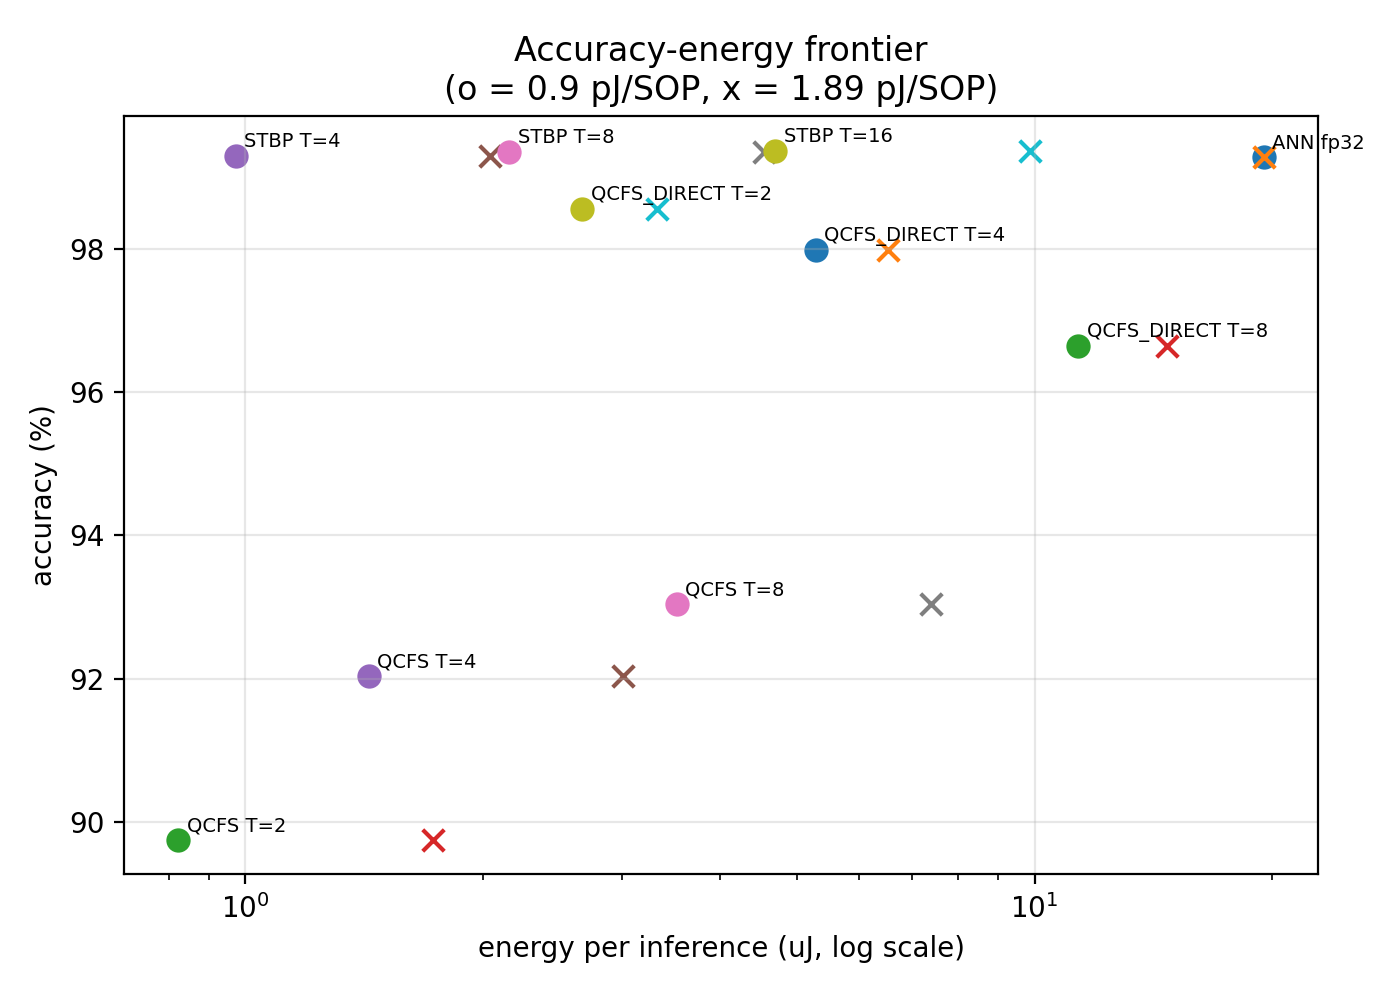

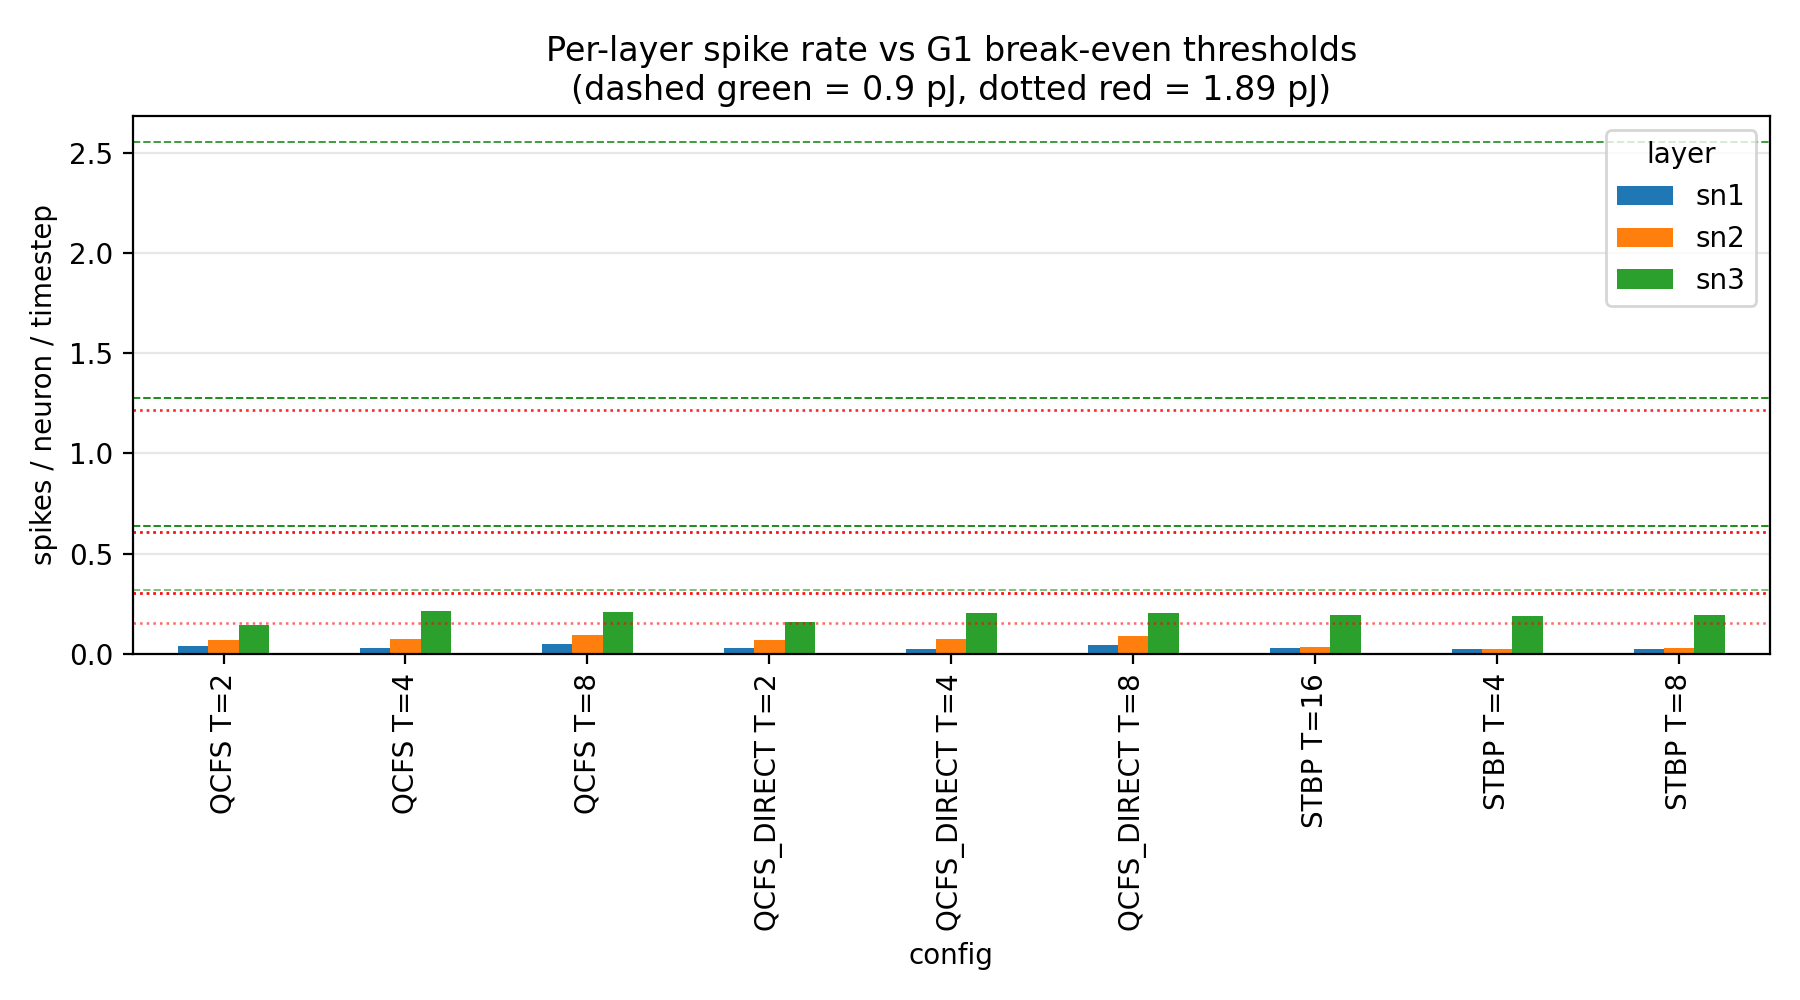

In [11]:
from IPython.display import Image, Markdown, display
display(Markdown(open(TABLES + '/thesis_tables.md').read()))
for f in ('fig_training_curves', 'fig_accuracy_energy', 'fig_spike_rates'):
    display(Image(FIGURES + '/' + f + '.png'))